In [7]:
print("11421111111_林小明")

11421111111_林小明


In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from pathlib import Path
from collections import defaultdict
from google.colab import drive

# 載入雲端硬碟
drive.mount('/content/drive')

# ==========================================
# 步驟：讀取數據
# ==========================================
DATA_PATH = "/content/drive/MyDrive/Colab Notebooks/data/CWRU_preprocessed_data3.npz"
data = np.load(DATA_PATH, allow_pickle=True)

Mounted at /content/drive


In [2]:
# 試著更改架構、優化器、LOSS... 降低模型大小，並試著讓train_acc與Val_acc最大化

def build_1d_cnn(input_shape, num_classes):
    model = models.Sequential([
        # 第一層卷積：捕捉局部震動特徵
        layers.Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=input_shape),
        layers.MaxPooling1D(pool_size=2),

        # 第二層卷積：捕捉更深層的特徵
        layers.Conv1D(filters=64, kernel_size=3, activation='relu'),
        layers.MaxPooling1D(pool_size=2),

        # 展平並進入全連接層
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.2), # 防止過擬合
        layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model


In [3]:
# ==========================================
# 步驟：準備數據
# ==========================================
# --- 選項：選擇要訓練的資料類型 ('raw' 或 'fft') ---
DATA_MODE = 'raw'  # 👈 在這裡切換 'raw' 或 'fft'
# ----------------------------------------------

X = data[DATA_MODE]
y = data['labels']
label_names = data['label_names']

# 1D-CNN 需要輸入維度為 (樣本數, 長度, 通道數)
# 這裡通道數為 1 (單感測器訊號)
X = X.reshape(X.shape[0], X.shape[1], 1)

# 切分訓練與測試集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"目前訓練模式: {DATA_MODE}")
print(f"訓練資料形狀: {X_train.shape}")

# 建立並顯示模型摘要
model = build_1d_cnn(input_shape=(X.shape[1], 1), num_classes=len(label_names))
model.summary()

目前訓練模式: raw
訓練資料形狀: (1600, 4096, 1)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 4094, 32)       │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 2047, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 2045, 64)       │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 1022, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 65408)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     4,186,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,192,772 (15.99 MB)

 Trainable params: 4,192,772 (15.99 MB)

 Non-trainable params: 0 (0.00 B)

In [4]:
# 開始訓練
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1
)

# 評估測試集
test_loss, test_acc = model.evaluate(X_test, y_test)


Epoch 1/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 8s 46ms/step - accuracy: 0.4535 - loss: 1.3941 - val_accuracy: 0.6625 - val_loss: 0.7769
Epoch 2/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.6965 - loss: 0.7012 - val_accuracy: 0.7750 - val_loss: 0.5610
Epoch 3/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.7632 - loss: 0.5629 - val_accuracy: 0.7688 - val_loss: 0.5273
Epoch 4/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.8181 - loss: 0.4764 - val_accuracy: 0.8000 - val_loss: 0.5042
Epoch 5/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.8611 - loss: 0.3759 - val_accuracy: 0.7937 - val_loss: 0.5700
Epoch 6/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.8806 - loss: 0.3299 - val_accuracy: 0.8000 - val_loss: 0.5862
Epoch 7/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9111 - loss: 0.2553 - val_accuracy: 0.8188 - val_loss: 0.6542
Epoch 8/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9396 - loss: 0.1794 - val_accuracy: 0.8313 - v

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8125 - loss: 0.9390

測試集準確度 (raw): 0.8125

Epoch     Train Acc      Val Acc        Total Score    
-------------------------------------------------------
1         0.9840         0.7750         1.7590         
2         0.9819         0.8125         1.7944         
3         0.9861         0.7688         1.7549         
4         0.9799         0.8062         1.7861         
5         0.9799         0.7937         1.7736         
6         0.9819         0.7875         1.7694         
7         0.9826         0.8375         1.8201         
8         0.9847         0.8000         1.7847         
9         0.9819         0.8125         1.7944         
10        0.9868         0.8125         1.7993         
11        0.9896         0.8000         1.7896         
12        0.9868         0.8062         1.7931         
13        0.9847         0.8250         1.8097         
14        0.9806         0.8125         1.7931         
15      

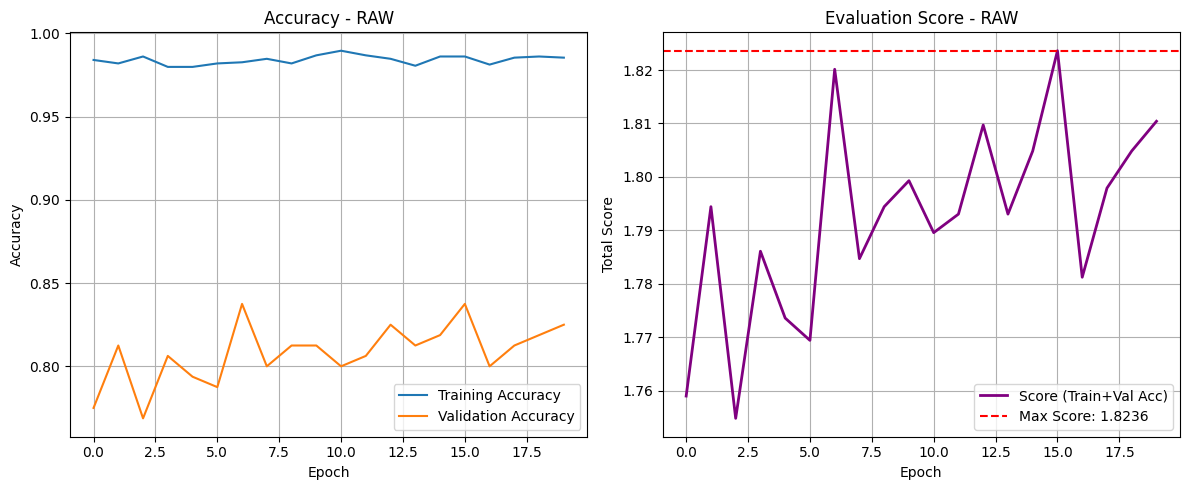

In [9]:
import matplotlib.pyplot as plt


# 評估測試集
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"\n測試集準確度 ({DATA_MODE}): {test_acc:.4f}")


# --------------------------------------------------------
# 遍歷 history 並計算評分 (TRAIN_ACC + VAL_ACC)
# 請不要更動此部分
##############################
train_acc_history = history.history['accuracy']
val_acc_history = history.history['val_accuracy']
combined_scores = []

print(f"\n{'Epoch':<10}{'Train Acc':<15}{'Val Acc':<15}{'Total Score':<15}")
print("-" * 55)

for i in range(len(train_acc_history)):
    t_acc = train_acc_history[i]
    v_acc = val_acc_history[i]
    score = t_acc + v_acc
    combined_scores.append(score)
    print(f"{i+1:<10}{t_acc:<15.4f}{v_acc:<15.4f}{score:<15.4f}")

# 找出最高評分
max_score = max(combined_scores)
max_score_epoch = combined_scores.index(max_score) + 1

print("-" * 55)
print(f"最高評分總和: {max_score:.4f} (發生於第 {max_score_epoch} 個 Epoch)")
# --------------------------------------------------------

# 繪製訓練曲線與評分曲線
plt.figure(figsize=(12, 5))

# 子圖 1: 準確度
plt.subplot(1, 2, 1)
plt.plot(train_acc_history, label='Training Accuracy')
plt.plot(val_acc_history, label = 'Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.title(f'Accuracy - {DATA_MODE.upper()}')
plt.grid(True)

# 子圖 2: 評分總和 (Score)
plt.subplot(1, 2, 2)
plt.plot(combined_scores, label='Score (Train+Val Acc)', color='purple', linewidth=2)
plt.axhline(y=max_score, color='r', linestyle='--', label=f'Max Score: {max_score:.4f}')
plt.xlabel('Epoch')
plt.ylabel('Total Score')
plt.legend(loc='lower right')
plt.title(f'Evaluation Score - {DATA_MODE.upper()}')
plt.grid(True)

plt.tight_layout()
plt.show()